# **MÓDULO 13**
# Projeto - Fundamentos da Descoberta de Dados

Nesse projeto trabalharemos com a base de dados de produtos de um supermercado do Chile.
A ideia é que vocês apliquem os conceitos estatísticos vistos no último módulo, mais os conceitos de visualizações de dados através de gráficos e finalizem publicando no seu github!

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

Faça a leitura dos dados do arquivo CSV:


Altere o código abaixo de acordo com seu diretório.

In [76]:
df = pd.read_csv("C:/Users/sidne/Downloads/MODULO7_PROJETOFINAL_BASE_SUPERMERCADO.csv")

df.head(10)

,title,Marca,Preco_Normal,Preco_Desconto,Preco_Anterior,Desconto,Categoria
0,"Pack 12 un, Leche extra proteína 1 L",Loncoleche,19788,0,0,0,lacteos
1,"Pack 12 un, Leche chocolate receta original 1 L",Soprole,18228,0,0,0,lacteos
2,"Pack 12 un, Leche semidescremada chocolate 1 L",Soprole,18228,0,0,0,lacteos
3,"Pack 12 un, Leche semidescremada frutilla 1 L",Soprole,18228,0,0,0,lacteos
4,"Pack 12 un, Leche sin lactosa chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
5,"Pack 12 un, Leche sin lactosa frutilla 1 L",Loncoleche,17988,0,0,0,lacteos
6,"Pack 12 un, Leche saborizada light chocolate 1 L",Loncoleche,17988,0,0,0,lacteos
7,"Pack 12 un, Leche saborizada frutilla 1 L",Colun,17388,0,0,0,lacteos
8,"Pack 12 un, Leche saborizada vainilla 1 L",Colun,17388,0,0,0,lacteos
9,"Pack 12 un, Leche saborizada manjar 1 L",Colun,17388,0,0,0,lacteos


Os campos do nosso dataframe são:

**Title:** Nome do produto.


**Marca:** A marca do produto.


**Preco_Normal:** O preço em que o produto costuma ser vendido quando não há desconto.


**Preco_Desconto:** O preço vendido após o desconto ser aplicado.


**Preco_Anterior:** Preço em que era comercializado o produto antes do desconto aplicado.


**Desconto:** Total de desconto aplicado.






As colunas que aparecem com valores 0 são para os produtos onde não tivemos descontos aplicados.


As categorias estão em espanhol!

# 1 - Traga a média e a mediana dos preços - coluna Preco_Normal - por categoria de produto.
# Identifique as categorias que parecem ter um valor de média abaixo ou acima da mediana.

In [77]:
# Tratando os dados

df['Categoria'] = df['Categoria'].str.title()
df['Preco_Normal'] = df['Preco_Normal'].astype(float)
df['Preco_Desconto'] = df['Preco_Desconto'].astype(float)
df['Preco_Anterior'] = df['Preco_Anterior'].astype(float)
df['Desconto'] = df['Desconto'].astype(float)


df['Preco_Normal'] = df['Preco_Normal']/100
df['Preco_Desconto'] = df['Preco_Desconto']/100
df['Preco_Anterior'] = df['Preco_Anterior']/100
df['Desconto'] = df['Desconto']/100
df.head(5)
# Calculando a média
df.groupby('Categoria')['Preco_Normal'].mean().reset_index().sort_values(by = 'Preco_Normal', ascending = False)


,Categoria,Preco_Normal
1,Comidas-Preparadas,30.950435
5,Lacteos,23.852192
2,Congelados,21.080426
0,Belleza-Y-Cuidado-Personal,17.835565
3,Frutas,17.244737
6,Verduras,13.432969
4,Instantaneos-Y-Sopas,7.654912


In [78]:
df.groupby('Categoria')['Preco_Normal'].median().reset_index().sort_values(by = 'Preco_Normal', ascending = False)



,Categoria,Preco_Normal
1,Comidas-Preparadas,32.90
0,Belleza-Y-Cuidado-Personal,15.69
2,Congelados,15.19
3,Frutas,11.95
6,Verduras,11.80
5,Lacteos,9.89
4,Instantaneos-Y-Sopas,4.39


Categorias de média abaixo da mediana: comidas-preparadas

Categorias de média acima da mediana: lacteos, congelados, frutas, verduras, instantaneos-y-sopas, belleza-y-cuidado-personal

# 2 - Traga o desvio padrão por categoria de produto.
# Qual o comportamento da média e mediana nas categorias com maior desvio?

In [79]:
df.groupby('Categoria')['Preco_Normal'].std().reset_index().sort_values(by = 'Preco_Normal', ascending = False)

,Categoria,Preco_Normal
5,Lacteos,39.258162
0,Belleza-Y-Cuidado-Personal,22.100417
2,Congelados,21.115399
1,Comidas-Preparadas,20.199114
3,Frutas,16.391511
4,Instantaneos-Y-Sopas,11.702329
6,Verduras,10.126996


A categoria com maior desvio possui uma grande descrepância do preço médio em comparação com a mediana.


# 3 - Plot um boxplot da distribuição do Preco_Normal para a categoria que você identificou que tem o maior desvio padrão. Como é a distribuição desses dados segundo o boxplot? Você identifica muitos outliers?

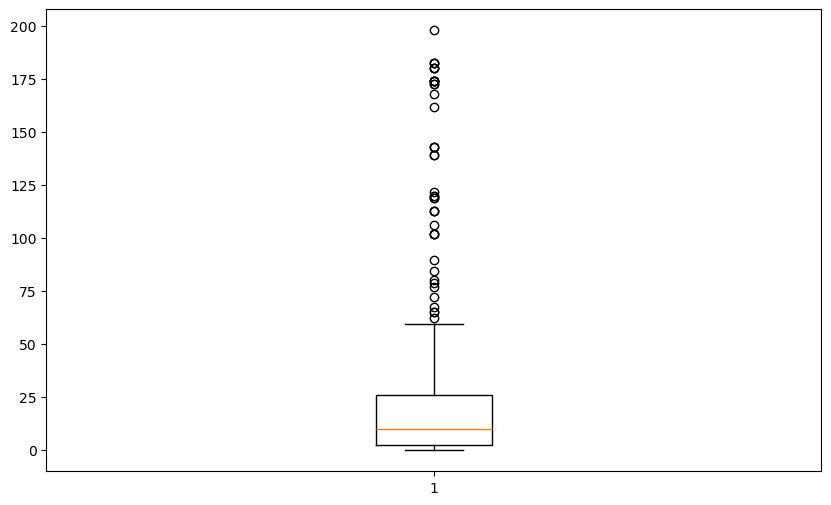

In [81]:
plt.figure(figsize = (10, 6))
plt.boxplot(df.loc[df['Categoria'] == 'Lacteos', 'Preco_Normal'])
plt.show()

Como o esperado, há muitos outliers pois o desvio padrão é muito alto.

# 4 - Plote um gráfico de barras onde temos a média de descontos por categoria.

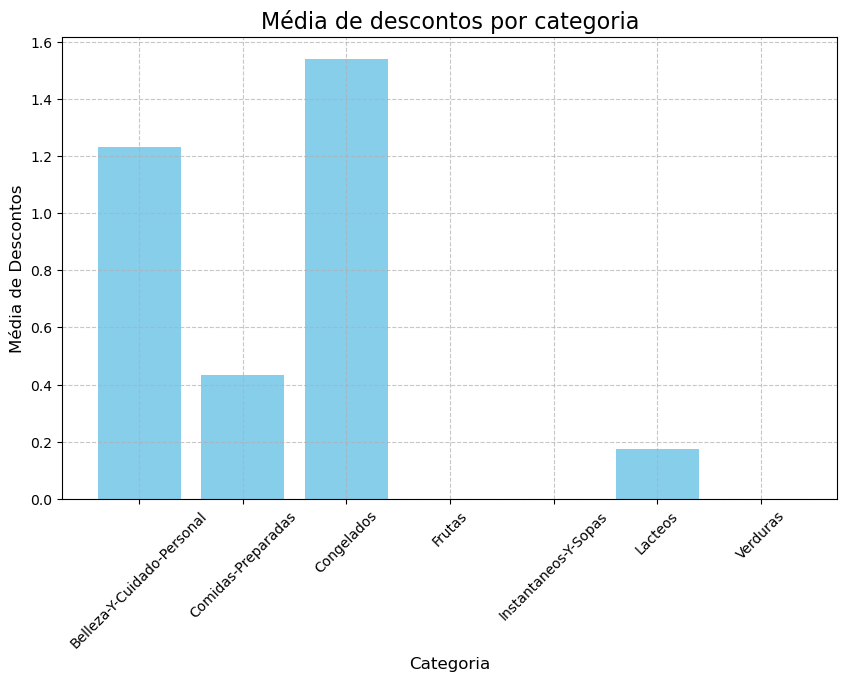

In [82]:
plt.figure(figsize = (10,6))
media_desconto = df.groupby('Categoria')['Desconto'].mean()
plt.bar(media_desconto.index, media_desconto, color = 'skyblue')
plt.title('Média de descontos por categoria', fontsize = 16)
plt.xlabel('Categoria', fontsize = 12)
plt.ylabel('Média de Descontos', fontsize = 12)
plt.xticks(rotation = 45)
plt.grid(True, linestyle = '--', alpha = 0.7)
plt.show()

# 5 - Plote um gráfico de mapa interativo agrupando os dados por categoria, marca e trazendo a média de desconto.

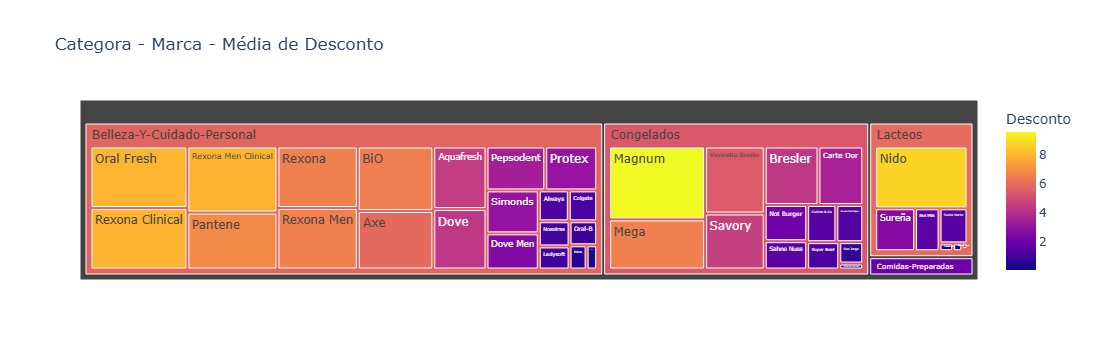

In [83]:
dados = df.groupby(['Categoria', 'Marca'])['Desconto'].mean().reset_index()

fig = px.treemap(dados, 
                 path = ['Categoria', 'Marca'],
                 values = 'Desconto',
                 title = 'Categora - Marca - Média de Desconto',
                 color = 'Desconto')
fig.show()
                 